## Instalações e Imports

In [ ]:
!pip install kagglehub tensorflow albumentations opencv-python-headless xgboost scikit-learn pandas matplotlib seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
import kagglehub
from pathlib import Path
from google.colab import drive
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score

Chamar Modelo Pré-treinado

In [ ]:
drive.mount('/content/drive')

# AJUSTE AQUI: Caminho da pasta e nome do arquivo do seu modelo
MODEL_DIR = '/content/drive/MyDrive/5º Período/ ML2/ Modelo'
MODEL_NAME = 'modelo_multimodal_final.keras' # Verifique se o nome está correto
FULL_MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

def categorical_focal_loss(gamma=2.0, alpha=0.75):
    def categorical_focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        modulating_factor = tf.pow(1.0 - y_pred, gamma)
        focal_loss = alpha * modulating_factor * cross_entropy
        return tf.reduce_sum(focal_loss, axis=-1)
    return categorical_focal_loss_fixed

print(f"Carregando modelo de: {FULL_MODEL_PATH}...")
try:
    # Carregamos o modelo mapeando a função customizada que você usou no treino
    meu_modelo = load_model(FULL_MODEL_PATH,
                            custom_objects={'categorical_focal_loss_fixed': categorical_focal_loss(gamma=2.0, alpha=0.75)})
    print("✅ Modelo carregado com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar o modelo: {e}")

Mounted at /content/drive
Carregando modelo de: /content/drive/MyDrive/5º Período/ ML2/ Modelo/modelo_multimodal_final.keras...
✅ Modelo carregado com sucesso!


## Download e Preparação dos Dados


In [ ]:
print("Preparando dados do HAM10000...")
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
DATA_DIR = Path(path)
IMG_DIRS = [DATA_DIR / 'HAM10000_images_part_1', DATA_DIR / 'HAM10000_images_part_2']

meta = pd.read_csv(DATA_DIR / 'HAM10000_metadata.csv')
meta['image_path'] = meta['image_id'].apply(lambda x: next((str(d/f"{x}.jpg") for d in IMG_DIRS if (d/f"{x}.jpg").exists()), None))
meta = meta.dropna(subset=['image_path']).reset_index(drop=True)

# Processamento Clínico (idêntico ao seu treino)
meta['age'] = meta['age'].fillna(meta['age'].median())
meta['sex'] = meta['sex'].map({'male': 0, 'female': 1, 'unknown': 2}).fillna(2)
meta['localization'] = meta['localization'].astype('category').cat.codes

le = LabelEncoder()
meta['label'] = le.fit_transform(meta['dx'])
class_names = list(le.classes_)

# Split para Teste
train_df, test_df = train_test_split(meta, test_size=0.2, stratify=meta['label'], random_state=42)

Preparando dados do HAM10000...
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


## EXTRAÇÃO DE FEATURES E COMPARAÇÃ

In [ ]:
feature_extractor = tf.keras.Model(inputs=meu_modelo.input,
                                  outputs=meu_modelo.get_layer('fused_dense_1').output)

def get_vectors(df, limit=2000):
    sample = df.sample(n=limit)
    imgs = np.array([cv2.cvtColor(cv2.resize(cv2.imread(p), (320, 320)), cv2.COLOR_BGR2RGB) / 255.0 for p in sample['image_path']])
    clins = sample[['age', 'sex', 'localization']].values.astype('float32')
    labels = sample['label'].values
    # Note que o seu modelo espera [Imagens, Dados Clínicos]
    feats = feature_extractor.predict([imgs, clins], verbose=0)
    return feats, labels, imgs, clins

print("\nExtraindo vetores de características...")
X_test_feats, y_test_labels, X_test_imgs, X_test_clins = get_vectors(test_df, limit=len(test_df))

# Algoritmos para comparar
modelos_ml = {
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "SVM": SVC(probability=True)
}

resultados = {}


Extraindo vetores de características...
Avaliando sua Rede Neural...
Testando Naive Bayes...
Testando Random Forest...
Testando XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:05:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Testando SVM...


In [ ]:
# 1. Avalia o SEU modelo original
print("Avaliando sua Rede Neural...")
y_pred_cnn = meu_modelo.predict([X_test_imgs, X_test_clins], verbose=0)
resultados["Sua Rede Neural (Drive)"] = accuracy_score(y_test_labels, np.argmax(y_pred_cnn, axis=1))

from sklearn.metrics import roc_auc_score
# Pre-calcula AUC para a CNN e modelos
resultados_auc = {}
try:
    resultados_auc["Sua Rede Neural (Drive)"] = roc_auc_score(y_test_labels, y_pred_cnn, multi_class="ovr")
except Exception as e:
    resultados_auc["Sua Rede Neural (Drive)"] = np.nan


In [ ]:
# 2. Avalia os modelos clássicos usando as features da sua rede
for nome, clf in modelos_ml.items():
    print(f"Testando {nome}...")
    # Aqui usamos uma amostra de treino rápida para os classificadores
    X_train_feats, y_train_labels, _, _ = get_vectors(train_df.sample(2000))
    clf.fit(X_train_feats, y_train_labels)
    y_pred = clf.predict(X_test_feats)
    resultados[nome] = accuracy_score(y_test_labels, y_pred)
    
    if hasattr(clf, "predict_proba"):
        y_probs = clf.predict_proba(X_test_feats)
        try:
            resultados_auc[nome] = roc_auc_score(y_test_labels, y_probs, multi_class="ovr")
        except:
            resultados_auc[nome] = np.nan
    else:
        resultados_auc[nome] = np.nan

## GRÁFICOS


--- Avaliando: Naive Bayes ---
Acurácia: 0.2167


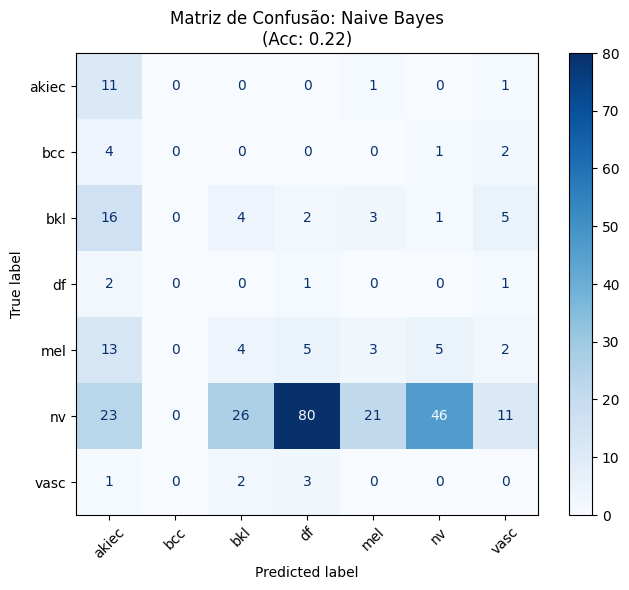


--- Avaliando: Random Forest ---
Acurácia: 0.6367


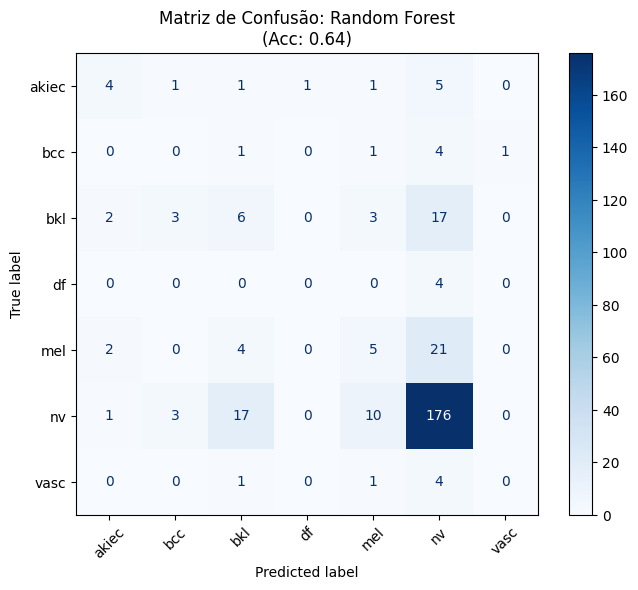


--- Avaliando: XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:16:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Acurácia: 0.6233


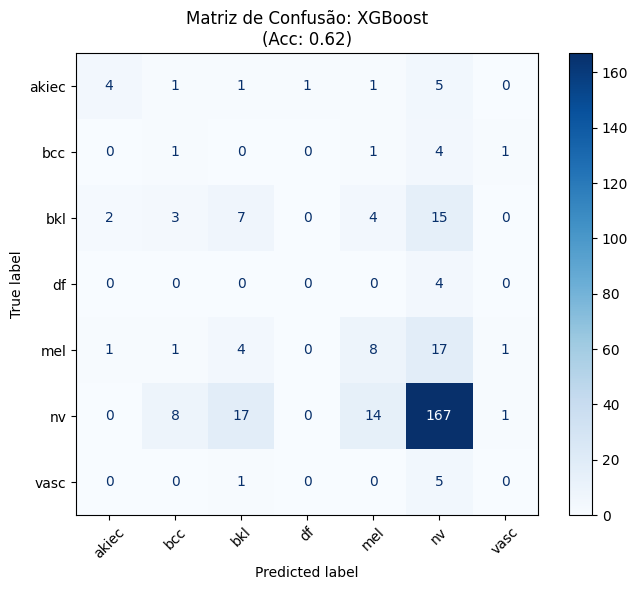


--- Avaliando: SVM ---
Acurácia: 0.6900


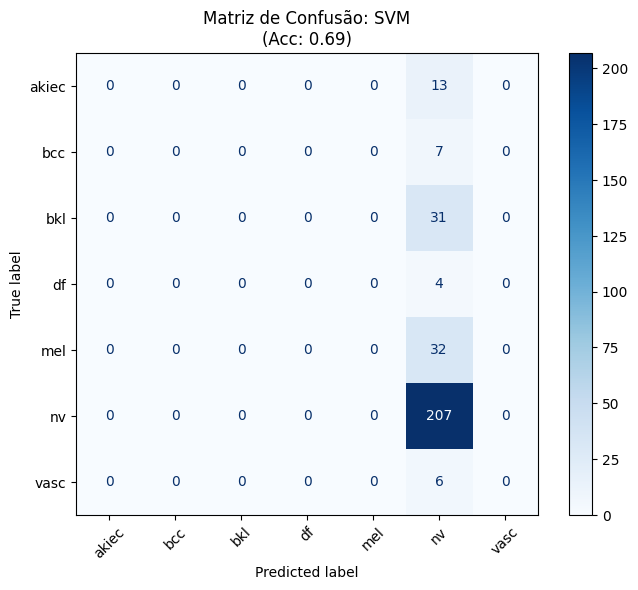

In [21]:
for nome, clf in modelos_ml.items():
    print(f"\n--- Avaliando: {nome} ---")

    if nome == "Sua Rede Neural (Drive)":
        y_probs = meu_modelo.predict([X_test_imgs, X_test_clins], verbose=0)
        y_pred = np.argmax(y_probs, axis=1)
    else:
        clf.fit(X_train_feats, y_train_labels)
        y_pred = clf.predict(X_test_feats)

    # Cálculo de Acurácia
    acc = accuracy_score(y_test_labels, y_pred)
    resultados[nome] = acc
    print(f"Acurácia: {acc:.4f}")

    # Plot da Matriz de Confusão
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test_labels, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Estilização: CNN em Vermelho, Clássicos em Azul
    cmap = plt.cm.Reds if nome == "Sua Rede Neural (CNN)" else plt.cm.Blues
    disp.plot(cmap=cmap, ax=ax, xticks_rotation=45)
    ax.set_title(f'Matriz de Confusão: {nome}\n(Acc: {acc:.2f})')
    plt.show()

/tmp/ipython-input-151/2173836318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')


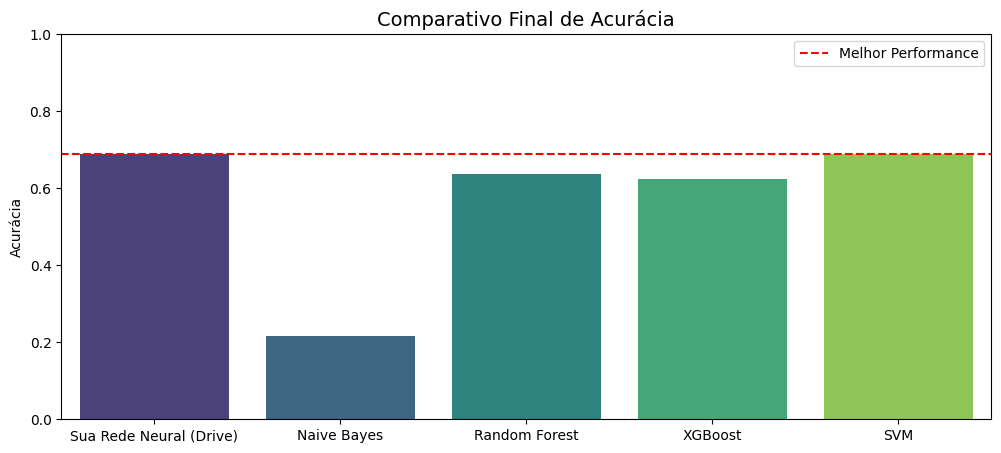

In [22]:
plt.figure(figsize=(12, 5))
sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')
plt.axhline(y=max(resultados.values()), color='r', linestyle='--', label='Melhor Performance')
plt.title('Comparativo Final de Acurácia', fontsize=14)
plt.ylabel('Acurácia')
plt.ylim(0, 1.0)
plt.legend()
plt.show()

In [26]:
modelos_ml

{'Naive Bayes': GaussianNB(),
 'Random Forest': RandomForestClassifier(),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...),
 'SVM': SVC(probability=True)}

Iniciando avaliação detalhada (Acurácia vs F1-Score)...

--- Analisando: Naive Bayes ---
   Acurácia: 0.2167 | F1-Score (Macro): 0.1228

--- Analisando: Random Forest ---
   Acurácia: 0.6300 | F1-Score (Macro): 0.2240

--- Analisando: XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:27:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Acurácia: 0.6233 | F1-Score (Macro): 0.2542

--- Analisando: SVM ---
   Acurácia: 0.6900 | F1-Score (Macro): 0.1167


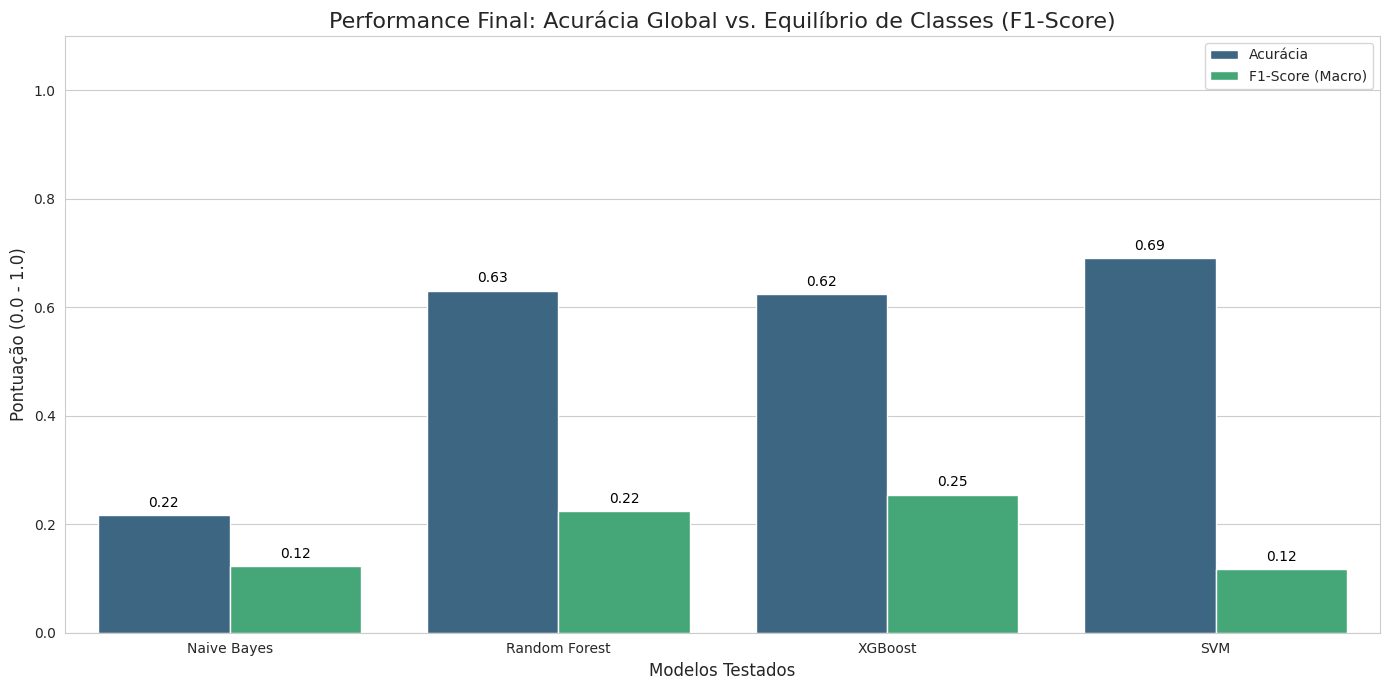


🏆 CONCLUSÃO: O modelo com melhor equilíbrio clínico (F1-Score) é: XGBoost


In [25]:
from sklearn.metrics import f1_score, classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionários para armazenar as métricas finais
resultados_acc = {}
resultados_f1 = {}
resultados_auc = {}

print("Iniciando avaliação detalhada (Acurácia vs F1-Score)...")

# 'modelos' deve ser o seu dicionário de classificadores (NB, RF, XGB, SVM)
for nome, clf in modelos_ml.items():
    print(f"\n--- Analisando: {nome} ---")

    # 1. Obter Predições
    if nome == "Sua Rede Neural (Drive)":
        # Avalia a sua CNN carregada do Drive
        y_probs = meu_modelo.predict([X_test_imgs, X_test_clins], verbose=0)
        y_pred = np.argmax(y_probs, axis=1)
    else:
        # Treina e prediz para os modelos de ML clássico
        clf.fit(X_train_feats, y_train_labels)
        y_pred = clf.predict(X_test_feats)

    # 2. Calcular Métricas
    acc = accuracy_score(y_test_labels, y_pred)
    # O 'macro' dá o mesmo peso para cada doença, revelando se o modelo é equilibrado
    f1 = f1_score(y_test_labels, y_pred, average='macro')
    
    # Calcular AUC
    try:
        if nome == "Sua Rede Neural (Drive)":
            auc = roc_auc_score(y_test_labels, y_probs, multi_class="ovr")
        elif hasattr(clf, "predict_proba"):
            y_probs_clf = clf.predict_proba(X_test_feats)
            auc = roc_auc_score(y_test_labels, y_probs_clf, multi_class="ovr")
        else:
            auc = np.nan
    except:
        auc = np.nan

    resultados_acc[nome] = acc
    resultados_f1[nome] = f1
    resultados_auc[nome] = auc

    print(f"   Acurácia: {acc:.4f} | F1-Score (Macro): {f1:.4f} | AUC (OVR): {auc:.4f}")

# Organizando os dados para o gráfico
df_metricas = pd.DataFrame({
    'Algoritmo': list(resultados_acc.keys()),
    'Acurácia': list(resultados_acc.values()),
    'F1-Score (Macro)': list(resultados_f1.values()),
    'AUC (OVR)': list(resultados_auc.values())
}).melt(id_vars='Algoritmo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Gráfico de barras agrupadas
ax = sns.barplot(data=df_metricas, x='Algoritmo', y='Valor', hue='Métrica', palette='viridis')

plt.title('Performance Final: Acurácia Global vs. Equilíbrio de Classes (F1-Score)', fontsize=16)
plt.ylabel('Pontuação (0.0 - 1.0)', fontsize=12)
plt.xlabel('Modelos Testados', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(loc='upper right')

# Adicionar os valores numéricos sobre as barras para facilitar a leitura
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10,
                    color='black', xytext=(0, 9),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# Resumo para o seu relatório técnico
melhor_f1 = max(resultados_f1, key=resultados_f1.get)
print(f"\n🏆 CONCLUSÃO: O modelo com melhor equilíbrio clínico (F1-Score) é: {melhor_f1}")